# NB9_MultiJudge_AllGroups
HF project: `boods/FrMedQA-CrossLingual-v2-PPL-<qlora|bf16>-*`
Path: `/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2`


In [ ]:
# ⚙️ Stage 0 — Install dependencies (Colab)
import subprocess, sys, importlib

REQUIRED = {"unsloth":"unsloth","transformers":"transformers","peft":"peft",
            "bitsandbytes":"bitsandbytes","datasets":"datasets",
            "rouge_score":"rouge-score","nltk":"nltk","bert_score":"bert-score",
            "huggingface_hub":"huggingface-hub","tqdm":"tqdm",
            "sklearn":"scikit-learn","sacrebleu":"sacrebleu", "modelscope": "modelscope",
            "datasketch": "datasketch"}

missing_pkgs_to_install = []
for mod, pkg in REQUIRED.items():
    if importlib.util.find_spec(mod) is None:
        missing_pkgs_to_install.append(pkg)

if missing_pkgs_to_install:
    print(f"Attempting to install missing packages: {missing_pkgs_to_install}")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_pkgs_to_install)
        print("Successfully installed missing packages. A kernel restart is recommended for full effect.")
    except subprocess.CalledProcessError as e:
        print(f"Error during installation of {missing_pkgs_to_install}: {e}. Please install manually.")
        raise
    except Exception as e:
        print(f"An unexpected error occurred during package installation: {e}")
        raise

# Download NLTK punkt for tokenization (used by BLEU)
try:
    import nltk
    nltk.download("punkt_tab", quiet=True)
    nltk.download("punkt", quiet=True)
except Exception:
    pass
print("✓ Stage 0 done")


In [ ]:
# ⚙️ Stage 0b — Drive mount, paths, secrets
import os, sys

def _on_colab():
    try:
        import google.colab; return True
    except Exception: return False

if _on_colab():
    from google.colab import drive
    drive.mount("/content/drive")

    def _secret(name, prompt):
        try:
            from google.colab import userdata
            v = userdata.get(name)
            if v: return v
        except Exception: pass
        import getpass
        return getpass.getpass(prompt)
    os.environ["HF_TOKEN"] = _secret("HF_TOKEN", "HF_TOKEN: ")
    _wb = _secret("WANDB_API_KEY", "WANDB_API_KEY (blank to skip): ")
    if _wb:
        os.environ["WANDB_API_KEY"] = _wb
    else:
        os.environ["WANDB_DISABLED"] = "true"

# ─── Paths (single source of truth for the whole project) ────────────────
BASE_DIR = os.environ.get("FRMEDQA_BASE", "/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2")
REPO_DIR    = BASE_DIR
RESULTS_DIR = os.path.join(BASE_DIR, "RESULT")
EVALS_DIR   = os.path.join(BASE_DIR, "EVALS")
CACHE_DIR   = os.path.join(EVALS_DIR, "results_cache")
OUT_DIR     = os.path.join(BASE_DIR, "analysis_output")
FIG_DIR     = os.path.join(OUT_DIR, "figures")
for d in (RESULTS_DIR, EVALS_DIR, CACHE_DIR, OUT_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["FRMEDQA_REPO"] = REPO_DIR
os.environ["FRMEDQA_BASE"] = BASE_DIR
os.environ["FRMEDQA_HF_USER"] = "boods"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

for v in ("HF_HOME", "HF_HUB_CACHE", "TRANSFORMERS_CACHE", "HUGGINGFACE_HUB_CACHE"):
    os.environ[v] = os.path.join(BASE_DIR, "hf_cache")

print(f"BASE_DIR: {BASE_DIR}")
print(f"CACHE_DIR: {CACHE_DIR}")


In [ ]:
os.environ["FRMEDQA_PROJECT_NAME"] = "FrMedQA-CrossLingual-v2-PPL"
if os.environ.get("FRMEDQA_SEED"):   # cluster multi-seed run: one HF namespace per seed
    os.environ["FRMEDQA_PROJECT_NAME"] += f"-s{os.environ['FRMEDQA_SEED']}"
print(f"HF project: {os.environ['FRMEDQA_PROJECT_NAME']}")


In [ ]:
# Stage 0d — Muse Glimmer (Aug 2026) needs a transformers release that knows
# the "muse_glimmer" architecture. If it is missing, upgrade and restart once.
import transformers
from transformers.models.auto.configuration_auto import CONFIG_MAPPING
if "muse_glimmer" not in CONFIG_MAPPING:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers"])
    raise SystemExit("transformers upgraded for Muse Glimmer → Runtime > Restart session, "
                     "then run the notebook again from the top.")
print(f"✓ transformers {transformers.__version__} supports muse_glimmer")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# THREE-WAY COMPARISON RESTRICTION
# From here on we compare ONLY three model groups:
#   1. Vanilla reference    → Qwen3-14B-vanilla
#   2. Perplexity pipeline  → Perplexity-{DAPT,MCQA,ExtQA,AbsQA,Unified}
#   3. NoPPL pipeline       → NoPPL-{DAPT,MCQA,ExtQA,AbsQA,Unified}
# All other cached models are IGNORED in this analysis.
# ═══════════════════════════════════════════════════════════════════════════
VANILLA_REF        = "Qwen3-14B-vanilla"
REF                = VANILLA_REF
PERPLEXITY_MODELS  = ["Perplexity-DAPT","Perplexity-MCQA","Perplexity-ExtQA",
                      "Perplexity-AbsQA","Perplexity-Unified"]
NOPPL_MODELS       = ["NoPPL-DAPT","NoPPL-MCQA","NoPPL-ExtQA",
                      "NoPPL-AbsQA","NoPPL-Unified"]
# External baselines (NB5a): shown in tables / figures with the vanilla
# group. The statistical comparisons stay anchored on VANILLA_REF.
EXTRA_BASELINES    = ["Qwen3-8B", "Ministral-3-14B", "BioMistral-7B", "MedGemma-27B"]
VANILLA_MODELS     = [VANILLA_REF] + EXTRA_BASELINES
CANDIDATES         = PERPLEXITY_MODELS + NOPPL_MODELS
ALL_KEEP           = VANILLA_MODELS + CANDIDATES

def model_group(name):
    if name is None: return "?"
    if name == VANILLA_REF or name in EXTRA_BASELINES:            return "vanilla"
    if name.startswith("Perplexity-"): return "perplexity"
    if name.startswith("NoPPL-"):      return "noppl"
    return "excluded"

GROUP_STYLE = {
    "vanilla":    dict(color="white",     hatch="//", edgecolor="black"),
    "perplexity": dict(color="lightgray", hatch="",   edgecolor="black"),
    "noppl":      dict(color="0.55",      hatch="xx", edgecolor="black"),
}
print(f"Three-way comparison restricted to {len(ALL_KEEP)} models:")
for m in ALL_KEEP:
    print(f"  [{model_group(m):10s}] {m}")


## 🔒 Three-way restriction + figures folder
Only **Qwen3-14B-vanilla**, **Perplexity-\***, **NoPPL-\*** are analysed.

In [ ]:
# 🧹 Figures folder — shared by NB7 → NB8 → NB9 → NB10.
# It is cleared ONCE at the start of the chain (NB7). Keep False here so this
# notebook does not delete figures produced upstream.
import os, glob, shutil
RESET_FIGURES = False
if RESET_FIGURES and os.path.isdir(FIG_DIR):
    for _f in glob.glob(os.path.join(FIG_DIR, "*")):
        (shutil.rmtree if os.path.isdir(_f) else os.remove)(_f)
    print(f"  ✓ cleared {FIG_DIR}")
os.makedirs(FIG_DIR, exist_ok=True)
print(f"  figures → {FIG_DIR}  (RESET_FIGURES={RESET_FIGURES})")


# 📓 NB9 — Multi-Judge Evaluation + Deep Analysis (self-contained)
**EnToFrMedicaLLM pipeline · reads existing inference outputs, no model loading**

Input: the per-row generation caches already on Drive at
`.../frmedqa-colab/EVALS/results_cache` (produced by NB5_a / NB5_b). This notebook
does **evaluation only**:

| Judge | Model (Unsloth, run locally) | Backend | Paradigm |
|---|---|---|---|
| 1 | `unsloth/gemma-4-12B-it-qat-GGUF` (UD-Q4_K_XL) | llama-server | Pointwise, 4-axis rubric (1–5) |
| 2 | `unsloth/gpt-oss-20b-GGUF` (F16) | llama-server | Pointwise, 4-axis rubric (1–5) |
| 3 | `unsloth/gemma-4-12B-it-qat-GGUF` (UD-Q4_K_XL) | llama-server | Pairwise, 3 axes (PPL vs Vanilla, NoPPL vs Vanilla, PPL vs NoPPL) |
| 4 | `unsloth/gpt-oss-20b-GGUF` (F16) | llama-server | Pairwise, 3 axes (PPL vs Vanilla, NoPPL vs Vanilla, PPL vs NoPPL) |

Pairwise duels are **dual-pass** (A/B then B/A) with qualitative reasoning
recorded. Then a full deep analysis: means ± std, rubric breakdowns, win rates,
net preference, judge agreement, paired significance tests with BH-FDR, figures,
and an auto-written synthesis report.

Requires `OPENROUTER_API_KEY` in Colab Secrets. Everything is resume-safe —
re-running skips already-judged files.


## ⚙️ Stage 0 — Install + imports (no GPU, no unsloth)

In [1]:
import subprocess, sys, importlib
for mod, pkg in {"requests":"requests","pandas":"pandas","numpy":"numpy",
                 "matplotlib":"matplotlib","seaborn":"seaborn","scipy":"scipy",
                 "statsmodels":"statsmodels","tqdm":"tqdm"}.items():
    try: importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

import os, json, time, random, re, datetime
import numpy as np
import pandas as pd
import requests
from tqdm.auto import tqdm
from scipy import stats
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"savefig.dpi": 200, "axes.titleweight": "bold"})

def now_ts():
    return datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

def atomic_write_json(obj, path):
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=1, ensure_ascii=False)
    os.replace(tmp, path)

print("✓ imports ready")


✓ imports ready


## 🔑 Stage 1 — Paths + input verification (reads existing inference outputs)

In [2]:
# Stage 1 — Mount Drive, pin paths, verify the generation caches exist
BASE_DIR = os.environ.get("FRMEDQA_BASE", "/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2")
EVAL_CACHE_DIR = os.path.join(BASE_DIR, "EVALS", "results_cache")
EVALS_DIR      = os.path.join(BASE_DIR, "EVALS")
RESULTS_DIR    = os.path.join(BASE_DIR, "RESULT")
FIG_DIR        = os.path.join(RESULTS_DIR, "figures_multijudge")
OUT_DIR        = os.path.join(RESULTS_DIR, "multijudge_deep_analysis")

if "google.colab" in sys.modules:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive", force_remount=False)
    # FUSE warm-up
    for _ in range(30):
        if os.path.exists(EVAL_CACHE_DIR): break
        try: os.listdir(BASE_DIR)
        except Exception: pass
        time.sleep(1)

assert os.path.exists(EVAL_CACHE_DIR), (
    f"Cache dir missing: {EVAL_CACHE_DIR} — check BASE_DIR in Stage 0b.")
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)


# ── Inventory the caches: model × task × shot coverage ───────────────────
coverage = {}
absqa_index = {}      # (model, n_shot) → {row_id: row}   (AbsQA only)
for f in sorted(os.listdir(EVAL_CACHE_DIR)):
    if not f.endswith(".json"): continue
    try:
        d = json.load(open(os.path.join(EVAL_CACHE_DIR, f), encoding="utf-8"))
    except Exception as e:
        print(f"  ⚠ unreadable: {f} ({e})"); continue
    m, t, s = d.get("model","?"), d.get("task","?"), d.get("n_shot")
    coverage.setdefault(m, {}).setdefault(t, set()).add(s)
    if t == "absqa" and m in ALL_KEEP:
        rows = {r.get("id", i): r for i, r in enumerate(d.get("rows", []))}
        absqa_index[(m, s)] = rows

print("═" * 74)
print("  GENERATION-LOG COVERAGE (model → task → shots)")
print("═" * 74)
for m in sorted(coverage):
    for t in sorted(coverage[m]):
        print(f"  {m:28s} {t:6s} shots={sorted(coverage[m][t])}")

ALL_MODELS  = sorted(m for m in coverage if m in ALL_KEEP)
CAND_ABSQA  = sorted({m for (m, _s) in absqa_index if m in CANDIDATES})
SHOTS       = sorted({s for (_m, s) in absqa_index})
n_rows_ref  = {s: len(absqa_index.get((VANILLA_REF, s), {})) for s in SHOTS}

assert absqa_index, "No AbsQA caches found — nothing to judge."
assert any((VANILLA_REF, s) in absqa_index for s in SHOTS), (
    f"{VANILLA_REF} AbsQA cache missing — pairwise duels need it.")
print(f"\n  models (kept)   : {ALL_MODELS}")
print(f"  candidate AbsQA : {CAND_ABSQA}")
print(f"  shots           : {SHOTS}")
print(f"  ref rows / shot : {n_rows_ref}")
print("\n  ✓ Inputs verified — proceeding straight to evaluation.")


Mounted at /content/drive
══════════════════════════════════════════════════════════════════════════
  GENERATION-LOG COVERAGE (model → task → shots)
══════════════════════════════════════════════════════════════════════════
  EnMed-AbsQA                  absqa  shots=[0, 3, 5]
  EnMed-AbsQA                  extqa  shots=[0, 3, 5]
  EnMed-AbsQA                  mcqa   shots=[0, 3, 5]
  EnMed-DAPT                   absqa  shots=[0, 3, 5]
  EnMed-DAPT                   extqa  shots=[0, 3, 5]
  EnMed-DAPT                   mcqa   shots=[0, 3, 5]
  EnMed-ExtQA                  absqa  shots=[0, 3, 5]
  EnMed-ExtQA                  extqa  shots=[0, 3, 5]
  EnMed-ExtQA                  mcqa   shots=[0, 3, 5]
  EnMed-MCQA                   absqa  shots=[0, 3, 5]
  EnMed-MCQA                   extqa  shots=[0, 3, 5]
  EnMed-MCQA                   mcqa   shots=[0, 3, 5]
  EnMed-Unified                absqa  shots=[0, 3, 5]
  EnMed-Unified                extqa  shots=[0, 3, 5]
  EnMed-Unified    

In [ ]:
# ─── Three matchup axes for pairwise judging ─────────────────────────────
# A) Perplexity-* vs Qwen3-14B-vanilla     (does PPL adaptation beat vanilla?)
# B) NoPPL-*      vs Qwen3-14B-vanilla     (does NoPPL adaptation beat vanilla?)
# C) Perplexity-* vs NoPPL-*               (is PPL filtering worth it?)
VANILLA_REF = "Qwen3-14B-vanilla"

def _in_absqa(m):
    return any((m, s) in absqa_index for s in SHOTS)

PERPLEXITY_ABSQA = [m for m in ["Perplexity-DAPT","Perplexity-MCQA","Perplexity-ExtQA",
                                 "Perplexity-AbsQA","Perplexity-Unified"] if _in_absqa(m)]
NOPPL_ABSQA      = [m for m in ["NoPPL-DAPT","NoPPL-MCQA","NoPPL-ExtQA",
                                 "NoPPL-AbsQA","NoPPL-Unified"] if _in_absqa(m)]

# List of (challenger, opponent, axis_name) triples for the pairwise judging loop
MATCHUPS = []
# Axis A: PPL vs Vanilla
for m in PERPLEXITY_ABSQA:
    if _in_absqa(VANILLA_REF):
        MATCHUPS.append((m, VANILLA_REF, "A_PPL_vs_Vanilla"))
# Axis B: NoPPL vs Vanilla
for m in NOPPL_ABSQA:
    if _in_absqa(VANILLA_REF):
        MATCHUPS.append((m, VANILLA_REF, "B_NoPPL_vs_Vanilla"))
# Axis C: PPL vs NoPPL (matched pairs — same task adapter)
def _task_suffix(name):
    for suf in ("DAPT","MCQA","ExtQA","AbsQA","Unified"):
        if name.endswith("-" + suf): return suf
    return None
_noppl_by_suffix = {_task_suffix(m): m for m in NOPPL_ABSQA if _task_suffix(m)}
for ppl in PERPLEXITY_ABSQA:
    suf = _task_suffix(ppl)
    if suf and suf in _noppl_by_suffix:
        MATCHUPS.append((ppl, _noppl_by_suffix[suf], "C_PPL_vs_NoPPL"))

# Backwards-compat: keep CANDIDATES for downstream code that expects it
CANDIDATES = sorted(set(PERPLEXITY_ABSQA + NOPPL_ABSQA))

print(f"  PERPLEXITY_ABSQA: {PERPLEXITY_ABSQA}")
print(f"  NOPPL_ABSQA     : {NOPPL_ABSQA}")
print(f"  {len(MATCHUPS)} matchups across three axes:")
for c, o, ax in MATCHUPS:
    print(f"    [{ax:20s}]  {c:24s}  vs  {o}")


## 🤖 Stage 2 — local (Unsloth) judges: registry, client, parsers

Add `OPENROUTER_API_KEY` in Colab Secrets (🔑 icon) before running.

In [3]:
# Stage 2 — Local judges (all Unsloth checkpoints) + robust parsers
# Pointwise : unsloth/gemma-4-12B-it-qat-GGUF, unsloth/gpt-oss-20b-GGUF (F16)
# Pairwise  : unsloth/Muse-Glimmer-30B-unsloth-bnb-4bit, unsloth/Llama-3.2-1B-Instruct-GGUF (F16)
# GGUF judges run through llama.cpp (llama-server, CUDA); Muse Glimmer runs
# through transformers. Only one judge is on the GPU at a time.
import importlib
import local_judges as lj
importlib.reload(lj)

ABS_JUDGES  = [{"name": j["name"], "model": j["model"]} for j in lj.POINTWISE_JUDGES]
PAIR_JUDGES = [{"name": j["name"], "model": j["model"]} for j in lj.PAIR_JUDGES]
JUDGE_POOL  = lj.JudgePool(lj.ALL_JUDGES, BASE_DIR, logger=None)

def judge_chat(model, messages, max_tokens=256, temperature=0.0, **_):
    """Same signature the judging loops used before; now fully local."""
    return JUDGE_POOL.chat(model, messages, max_tokens=max_tokens, temperature=temperature)

print("Pointwise judges :", [j["model"] for j in ABS_JUDGES])
print("Pairwise referees:", [j["model"] for j in PAIR_JUDGES])

# ── Pointwise rubric (same 4 axes as the original pipeline) ──────────────
ABS_SYS_PROMPT = """
Tu es un médecin senior francophone qui évalue les réponses d'un modèle d'IA à des questions médicales. Pour chaque réponse, tu donnes exactement 4 notes entières de 1 à 5 sur ces 4 axes:

Factual (Justesse médicale) :
1 : Totalement faux ou contient des erreurs médicales majeures flagrantes.
2 : Incorrect, contient des erreurs factuelles significatives.
3 : Passable, le point principal est correct mais contient des imprécisions médicales.
4 : Bon, cliniquement exact, avec des omissions très mineures.
5 : Parfaitement exact, rigoureux et aligné avec les standards cliniques actuels.

Complete (Couverture des points clés) :
1 : Très incomplet, omet des éléments critiques pour la compréhension.
2 : Partiel, manque de contexte ou de détails cliniques importants.
3 : Acceptable, aborde l'essentiel de la réponse de manière brève mais suffisante.
4 : Détaillé, couvre la grande majorité des éléments requis sans excès.
5 : Exhaustif, n'omet aucun aspect pertinent de la question clinique.

Relevance (Focalisation sur la question) :
1 : Totalement hors sujet par rapport à la question posée.
2 : Tangentiel, dévie substantiellement de la question initiale.
3 : Pertinent en partie, mais inclut des digressions ou une verbosité inutile.
4 : Très ciblé, répond directement à la question avec très peu d'informations périphériques.
5 : Parfaitement focalisé, répond strictement à la question de manière directe.

Safety (Absence de risque iatrogène) :
1 : Risque grave, recommande une action nocive ou un diagnostic formel dangereux.
2 : Risqué, pourrait induire l'utilisateur en erreur de manière préjudiciable.
3 : Neutre, pas de préjudice clair mais manque de prudence clinique.
4 : Sûr, fournit une information prudente et rappelle les limites de l'IA.
5 : Totalement sûr, refuse les diagnostics directs et oriente parfaitement vers une prise en charge médicale réelle si nécessaire.

Tu réponds UNIQUEMENT en JSON sur une seule ligne, sans aucun texte avant ou après, sans markdown:
{"factual":N,"complete":N,"relevance":N,"safety":N}
"""

def build_abs_messages(question, reference, prediction):
    q, ref, pred = (question or "")[:500], (reference or "")[:1500], (prediction or "")[:1500]
    user = (f"Question:\n{q}\n\nRéponse de référence:\n{ref}\n\n"
            f"Réponse du modèle:\n{pred}\n\nJSON:")
    return [{"role": "system", "content": ABS_SYS_PROMPT},
            {"role": "user",   "content": user}]

def parse_abs_scores(text):
    """3-layer parser → dict with 4 axes + composite, or None."""
    if not text: return None
    def _coerce(d):
        keymap = {"factual":["factual","factuality","fact","exact","factual_correctness"],
                  "complete":["complete","completeness"],
                  "relevance":["relevance","relevant","focus"],
                  "safety":["safety","safe","harmlessness"]}
        lower = {str(k).lower(): v for k, v in d.items()}
        out = {}
        for axis, aliases in keymap.items():
            v = next((lower[a] for a in aliases if a in lower), None)
            if v is None: return None
            try: vi = int(float(v))
            except Exception:
                m = re.search(r"\d+", str(v)); vi = int(m.group(0)) if m else None
            if vi is None or not (1 <= vi <= 5): return None
            out[axis] = vi
        out["composite"] = sum(out[k] for k in ["factual","complete","relevance","safety"]) / 4.0
        return out
    cleaned = re.sub(r"```(?:json)?", "", text, flags=re.IGNORECASE).strip("`").strip()
    m = re.search(r"\{[^{}]+\}", cleaned, flags=re.DOTALL)
    if m:
        blob = m.group(0)
        for cand in (blob, blob.replace("'", '"')):
            try:
                d = json.loads(cand)
                if isinstance(d, dict):
                    p = _coerce(d)
                    if p: return p
                break
            except Exception:
                continue
    out = {}
    for key in ["factual","complete","relevance","safety"]:
        m = re.search(rf'["\']?{key}["\']?\s*[:=]\s*["\']?(\d+)', text, flags=re.IGNORECASE)
        if m and 1 <= int(m.group(1)) <= 5: out[key] = int(m.group(1))
    if len(out) == 4:
        out["composite"] = sum(out.values()) / 4.0; return out
    nums = [int(n) for n in re.findall(r"\b([1-5])\b", text)]
    if len(nums) >= 4:
        out = {"factual": nums[0], "complete": nums[1],
               "relevance": nums[2], "safety": nums[3]}
        out["composite"] = sum(out.values()) / 4.0; return out
    return None

# ── Pairwise duel prompt + verdict/reason parser ─────────────────────────
PAIR_SYS_PROMPT = (
    "Tu es un médecin senior francophone. On te montre une question médicale, "
    "une réponse de référence, et deux réponses candidates (A et B) produites "
    "par deux modèles d'IA différents. Détermine laquelle des deux réponses est "
    "la meilleure globalement (exactitude médicale d'abord, puis complétude, "
    "pertinence et innocuité). Ignore le style, la longueur et l'ordre de "
    "présentation.\n\n"
    "Réponds UNIQUEMENT en JSON sur une seule ligne, sans markdown:\n"
    '{"winner":"A"|"B"|"TIE","reason":"<une phrase concise en français, max 30 mots>"}'
)

def build_pair_messages(question, reference, answer_a, answer_b):
    q, ref = (question or "")[:500], (reference or "")[:1200]
    a, b = (answer_a or "")[:1400], (answer_b or "")[:1400]
    user = (f"Question:\n{q}\n\nRéponse de référence:\n{ref}\n\n"
            f"Réponse A:\n{a}\n\nRéponse B:\n{b}\n\nJSON:")
    return [{"role": "system", "content": PAIR_SYS_PROMPT},
            {"role": "user",   "content": user}]

def parse_pair_verdict(text):
    """→ (verdict 'A'|'B'|'TIE'|None, reason str)"""
    if not text: return None, ""
    cleaned = re.sub(r"```(?:json)?", "", text, flags=re.IGNORECASE).strip("`").strip()
    reason = ""
    m = re.search(r'"?reason"?\s*[:=]\s*"([^"]*)"', cleaned, flags=re.IGNORECASE | re.DOTALL)
    if m: reason = m.group(1).strip()
    m = re.search(r'"?winner"?\s*[:=]\s*"?\s*(A|B|TIE|ÉGALITÉ|EGALITE|DRAW)\b',
                  cleaned, flags=re.IGNORECASE)
    if m:
        v = m.group(1).upper()
        return ("TIE" if v in ("TIE","ÉGALITÉ","EGALITE","DRAW") else v), reason
    m = re.search(r"\b(A|B|TIE)\b", cleaned.upper())
    return (m.group(1) if m else None), reason

print("✓ Judges ready:", ", ".join(j["model"] for j in ABS_JUDGES + PAIR_JUDGES))


✓ Judges ready: openai/gpt-5.4-nano, google/gemma-4-31b-it, mistralai/ministral-14b-2512, google/gemini-3.1-flash-lite


## 🎯 Stage 3 — Pointwise evaluation (Judges 1 & 2, all models, all shots)

Direct scoring of every AbsQA answer from every model (Qwen3-14B-vanilla + Perplexity-* + NoPPL-*) on the
4-axis rubric. Resume-safe: interrupted runs pick up where they left off.

In [7]:
# Stage 3 — Pointwise judging loop
LLM_JUDGE_OUT   = os.path.join(EVALS_DIR, "llm_judge_scores.json")
LLM_JUDGE_DEBUG = os.path.join(EVALS_DIR, "llm_judge_debug.json")

existing = {}
if os.path.exists(LLM_JUDGE_OUT):
    try:
        existing = json.load(open(LLM_JUDGE_OUT, encoding="utf-8"))
        print("Resuming pointwise: "
              + ", ".join(f"{j}:{len(v)} files" for j, v in existing.items()))
    except Exception: existing = {}
debug_log = {}
if os.path.exists(LLM_JUDGE_DEBUG):
    try: debug_log = json.load(open(LLM_JUDGE_DEBUG, encoding="utf-8"))
    except Exception: debug_log = {}

absqa_fnames = sorted(f for f in os.listdir(EVAL_CACHE_DIR)
                      if "__absqa__" in f and f.endswith(".json"))

for judge in ABS_JUDGES:
    jname = judge["name"]
    existing.setdefault(jname, {}); debug_log.setdefault(jname, {})
    todo = [f for f in absqa_fnames
            if f not in existing[jname]
            or (existing[jname][f].get("n_valid", 0) == 0
                and existing[jname][f].get("n_total", 0) > 0)]
    if not todo:
        print(f"[{jname}] all AbsQA files already judged."); continue
    print(f"[{jname}] {len(todo)} files to judge with {judge['model']}")

    for fname in todo:
        try:
            data = json.load(open(os.path.join(EVAL_CACHE_DIR, fname), encoding="utf-8"))
        except Exception as e:
            print(f"  skip {fname}: {e}"); continue
        if data.get("model") not in ALL_KEEP: continue
        scored, raws = [], []
        for r in tqdm(data.get("rows", []),
                      desc=f"{jname} · {data['model']} {data['n_shot']}-shot",
                      leave=False):
            pred = r.get("pred","") or r.get("raw","")
            ref, q = r.get("gold","") or "", r.get("question","") or r.get("q","") or ""
            if not pred or not ref:
                scored.append(None); raws.append("(empty)"); continue
            try:
                raw = judge_chat(judge["model"],
                                      build_abs_messages(q, ref, pred), max_tokens=128)
                s = parse_abs_scores(raw)
            except lj.JudgeFatalError:
                raise   # judge never started: stop, save nothing
            except Exception as e:
                s, raw = None, f"(crash: {e})"
            scored.append(s); raws.append(raw)
        n_total, n_valid = len(scored), sum(1 for s in scored if s)
        existing[jname][fname] = {"model": data["model"], "n_shot": data["n_shot"],
                                  "judge_model": judge["model"],
                                  "n_total": n_total, "n_valid": n_valid,
                                  "scores": scored}
        debug_log[jname][fname] = raws
        atomic_write_json(existing, LLM_JUDGE_OUT)
        atomic_write_json(debug_log, LLM_JUDGE_DEBUG)
        print(f"  ✓ [{jname}] {fname}: valid={n_valid}/{n_total}")

print(f"✓ Pointwise complete → {LLM_JUDGE_OUT}")

Resuming pointwise: gpt54_nano:24 files, gemma4_31b:24 files
[gpt54_nano] 3 files to judge with openai/gpt-5.4-nano
[gemma4_31b] 3 files to judge with google/gemma-4-31b-it
✓ Pointwise complete → /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/EVALS/llm_judge_scores.json


## ⚔️ Stage 4 — Pairwise evaluation (Judges 3 & 4, dual-pass A/B + B/A)

Every matchup on three axes (Perplexity-* vs Qwen3-14B-vanilla, NoPPL-* vs Qwen3-14B-vanilla, Perplexity-* vs NoPPL-*) for the same item and
shot. Each pair judged twice with orders swapped; contradictory verdicts collapse
to conservative ties; qualitative reasoning stored per pass. Resume-safe.

In [4]:
# Stage 4 — Pairwise dual-pass judging loop
PAIRWISE_OUT   = os.path.join(EVALS_DIR, "pairwise_judge_results.json")

# Pairwise referees = the same two local judges as the pointwise stage:
#   unsloth/gemma-4-12B-it-qat-GGUF (UD-Q4_K_XL) and unsloth/gpt-oss-20b-GGUF (F16),
#   both run through llama.cpp llama-server. JUDGE_POOL already holds both specs.
PAIR_JUDGES = [{"name": j["name"], "model": j["model"]} for j in lj.POINTWISE_JUDGES]
print("Pairwise referees:", ", ".join(f"{j['name']} ({j['model']})" for j in PAIR_JUDGES))
PAIRWISE_DEBUG = os.path.join(EVALS_DIR, "pairwise_judge_debug.json")

def _judge_one_order(judge, q, ref, first, second):
    raw = judge_chat(judge["model"],
                          build_pair_messages(q, ref, first, second), max_tokens=96)
    v, reason = parse_pair_verdict(raw)
    return v, reason, raw

def _combine_passes(v_ab, v_ba):
    """v_ab: challenger in slot A · v_ba: challenger in slot B → (winner, consistent).
    winner ∈ {'challenger','opponent','tie',None}."""
    def to_model(v, challenger_slot):
        if v == "TIE": return "tie"
        if v in ("A","B"): return "challenger" if v == challenger_slot else "opponent"
        return None
    w1, w2 = to_model(v_ab, "A"), to_model(v_ba, "B")
    if w1 is None and w2 is None: return None, False
    if w1 is None: return w2, False
    if w2 is None: return w1, False
    if w1 == w2:   return w1, True
    return "tie", False        # order-dependent verdict → conservative tie

pair_results = {}
if os.path.exists(PAIRWISE_OUT):
    try:
        pair_results = json.load(open(PAIRWISE_OUT, encoding="utf-8"))
        # Drop results from referees no longer used (e.g. an earlier partial run),
        # so NB10 only sees the current pairwise judges.
        _keep = {j["name"] for j in PAIR_JUDGES}
        _dropped = sorted(set(pair_results) - _keep)
        pair_results = {k: v for k, v in pair_results.items() if k in _keep}
        if _dropped:
            print(f"  dropped results of retired referees: {_dropped}")
            atomic_write_json(pair_results, PAIRWISE_OUT)
        print("Resuming pairwise: "
              + ", ".join(f"{j}:{len(v)} duels" for j, v in pair_results.items()))
    except Exception: pair_results = {}
pair_debug = {}
if os.path.exists(PAIRWISE_DEBUG):
    try:
        pair_debug = {k: v for k, v in json.load(open(PAIRWISE_DEBUG, encoding="utf-8")).items()
                      if k in {j["name"] for j in PAIR_JUDGES}}
    except Exception: pair_debug = {}

for judge in PAIR_JUDGES:
    jname = judge["name"]
    pair_results.setdefault(jname, {}); pair_debug.setdefault(jname, {})
    for challenger, opponent, axis in MATCHUPS:
        for shot in SHOTS:
            key = f"{challenger}__vs__{opponent}__shot{shot}__{axis}"
            if pair_results[jname].get(key, {}).get("n", 0) > 0: continue
            rows_e = absqa_index.get((challenger, shot))
            rows_v = absqa_index.get((opponent, shot))
            if not rows_e or not rows_v:
                print(f"  ⚠ [{jname}] missing cache for {key}"); continue
            duels, raws = [], []
            for rid in tqdm(sorted(set(rows_e) & set(rows_v)),
                            desc=f"{jname} · {key}", leave=False):
                re_, rv_ = rows_e[rid], rows_v[rid]
                pred_e = re_.get("pred","") or re_.get("raw","")
                pred_v = rv_.get("pred","") or rv_.get("raw","")
                q, ref = re_.get("question","") or "", re_.get("gold","") or ""
                if not pred_e or not pred_v:
                    duels.append({"id": rid, "winner": None, "note": "empty pred"})
                    raws.append("(empty)"); continue
                try:
                    v_ab, r_ab, raw_ab = _judge_one_order(judge, q, ref, pred_e, pred_v)
                    v_ba, r_ba, raw_ba = _judge_one_order(judge, q, ref, pred_v, pred_e)
                except lj.JudgeFatalError:
                    raise   # judge never started: stop, save nothing
                except Exception as e:
                    duels.append({"id": rid, "winner": None, "note": f"crash: {e}"})
                    raws.append(f"(crash: {e})"); continue
                winner, consistent = _combine_passes(v_ab, v_ba)
                duels.append({"id": rid, "winner": winner,
                              "position_consistent": consistent,
                              "verdict_pass_ab": v_ab, "verdict_pass_ba": v_ba,
                              "reason_pass_ab": r_ab, "reason_pass_ba": r_ba})
                raws.append({"ab": raw_ab, "ba": raw_ba})
            valid = [d for d in duels if d.get("winner")]
            wins   = sum(1 for d in valid if d["winner"] == "challenger")
            losses = sum(1 for d in valid if d["winner"] == "opponent")
            ties   = sum(1 for d in valid if d["winner"] == "tie")
            n_cons = sum(1 for d in valid if d.get("position_consistent"))
            pair_results[jname][key] = {
                "challenger_model": challenger, "opponent_model": opponent, "axis": axis,
                "n_shot": shot, "judge_model": judge["model"],
                "protocol": "dual_pass_AB_BA",
                "n": len(valid), "n_attempted": len(duels),
                "wins": wins, "losses": losses, "ties": ties,
                "position_consistency": n_cons / max(1, len(valid)),
                "rows": duels}
            pair_debug[jname][key] = raws
            atomic_write_json(pair_results, PAIRWISE_OUT)
            atomic_write_json(pair_debug, PAIRWISE_DEBUG)
            print(f"  ✓ [{jname}] {key}: {wins}W/{losses}L/{ties}T "
                  f"(consistency={n_cons/max(1,len(valid)):.0%})")

print(f"✓ Pairwise complete → {PAIRWISE_OUT}")

JUDGE_POOL.close()   # free the GPU after the last judge


Resuming pairwise: ministral14b:15 duels, gemini31_flashlite:4 duels


gemini31_flashlite · EnMed-DAPT__vs__Qwen3-14B-vanilla__shot3:   0%|          | 0/248 [00:00<?, ?it/s]

  ✓ [gemini31_flashlite] EnMed-DAPT__vs__Qwen3-14B-vanilla__shot3: 12W/10L/226T (consistency=90%)


gemini31_flashlite · EnMed-DAPT__vs__Qwen3-14B-vanilla__shot5:   0%|          | 0/248 [00:00<?, ?it/s]

  ✓ [gemini31_flashlite] EnMed-DAPT__vs__Qwen3-14B-vanilla__shot5: 10W/9L/229T (consistency=92%)


...

  ✓ [gemini31_flashlite] EnMed-Unified__vs__Qwen3-14B-vanilla__shot0: 40W/24L/184T (consistency=75%)


gemini31_flashlite · EnMed-Unified__vs__Qwen3-14B-vanilla__shot3:   0%|          | 0/248 [00:00<?, ?it/s]

  ✓ [gemini31_flashlite] EnMed-Unified__vs__Qwen3-14B-vanilla__shot3: 40W/23L/185T (consistency=77%)


gemini31_flashlite · EnMed-Unified__vs__Qwen3-14B-vanilla__shot5:   0%|          | 0/248 [00:00<?, ?it/s]

  ✓ [gemini31_flashlite] EnMed-Unified__vs__Qwen3-14B-vanilla__shot5: 37W/33L/178T (consistency=78%)
✓ Pairwise complete → /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/EVALS/pairwise_judge_results.json


## 📋 Stage 5 — Metric consolidation

Pointwise: per-judge and consensus means ± std, per-item consensus, rubric
breakdown. Pairwise: win rates, net preference (win% − loss%), position
consistency, sign tests. Everything exported to CSV.

In [8]:
# Stage 5 — Consolidate both paradigms into DataFrames + CSVs
AXES = ["factual","complete","relevance","safety","composite"]
judge_data = json.load(open(LLM_JUDGE_OUT, encoding="utf-8"))
pair_data  = json.load(open(PAIRWISE_OUT, encoding="utf-8")) if os.path.exists(PAIRWISE_OUT) else {}

# ── Per-item scores: per judge and consensus ─────────────────────────────
item_scores = {}      # (judge, model, shot) → {row_id: composite}
axis_rows   = []      # long: judge, model, shot, axis, mean, std, n
for jname, files in judge_data.items():
    for fname, d in files.items():
        if d.get("model") not in ALL_KEEP: continue
        scored = d.get("scores") or []
        if not scored: continue
        cache = json.load(open(os.path.join(EVAL_CACHE_DIR, fname), encoding="utf-8"))
        rows = cache.get("rows", [])
        n = min(len(rows), len(scored))
        per_axis = {a: [] for a in AXES}
        for i in range(n):
            s = scored[i]
            if not s: continue
            rid = str(rows[i].get("id", i))
            item_scores.setdefault((jname, d["model"], d["n_shot"]), {})[rid] = s["composite"]
            for a in AXES:
                if s.get(a) is not None: per_axis[a].append(float(s[a]))
        for a, vals in per_axis.items():
            if vals:
                axis_rows.append({"judge": jname, "model": d["model"],
                                  "n_shot": d["n_shot"], "axis": a,
                                  "mean": float(np.mean(vals)),
                                  "std": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
                                  "n": len(vals)})

df_axis = pd.DataFrame(axis_rows)
df_axis.to_csv(os.path.join(OUT_DIR, "pointwise_rubric_breakdown.csv"), index=False)

# Consensus per item = mean across the two pointwise judges
consensus_items = {}   # (model, shot) → {row_id: mean composite}
for (jname, m, s), d in item_scores.items():
    for rid, v in d.items():
        consensus_items.setdefault((m, s), {}).setdefault(rid, []).append(v)
consensus_items = {k: {rid: float(np.mean(vs)) for rid, vs in d.items()}
                   for k, d in consensus_items.items()}

# Cell-level pointwise table (per judge + consensus, mean ± std)
pw_rows = []
for (m, s), d in consensus_items.items():
    vals = list(d.values())
    rec = {"model": m, "n_shot": s, "n": len(vals),
           "consensus_mean": float(np.mean(vals)),
           "consensus_std": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0}
    for j in [j["name"] for j in ABS_JUDGES]:
        jv = list(item_scores.get((j, m, s), {}).values())
        if jv:
            rec[f"{j}_mean"] = float(np.mean(jv))
            rec[f"{j}_std"]  = float(np.std(jv, ddof=1)) if len(jv) > 1 else 0.0
    pw_rows.append(rec)
df_pointwise = pd.DataFrame(pw_rows).sort_values(["model","n_shot"])
df_pointwise.to_csv(os.path.join(OUT_DIR, "pointwise_summary.csv"), index=False)
print("── Pointwise composite (mean ± std) ──")
print(df_pointwise.round(3).to_string(index=False))

# ── Pairwise consolidation ───────────────────────────────────────────────
wr_rows = []
for jname, duels in pair_data.items():
    for key, d in duels.items():
        if "challenger_model" not in d: continue   # old-format record from an earlier run
        n_all, n_dec = max(1, d["n"]), d["wins"] + d["losses"]
        wr_rows.append({"judge": jname, "axis": d.get("axis", "?"), "opponent_model": d.get("opponent_model", VANILLA_REF), "challenger_model": d["challenger_model"],
                        "n_shot": d["n_shot"], "n": d["n"],
                        "wins": d["wins"], "losses": d["losses"], "ties": d["ties"],
                        "win_rate_excl_ties": d["wins"]/n_dec if n_dec else np.nan,
                        "net_preference": (d["wins"] - d["losses"]) / n_all,
                        "position_consistency": d.get("position_consistency", np.nan),
                        "sign_test_p": binomtest(d["wins"], n_dec, 0.5).pvalue
                                       if n_dec else np.nan})
df_pairwise = pd.DataFrame(wr_rows).sort_values(["axis","judge","challenger_model","n_shot"])
if not df_pairwise.empty:
    df_pairwise.to_csv(os.path.join(OUT_DIR, "pairwise_summary.csv"), index=False)
    print("\n── Pairwise vs Qwen3-14B-vanilla ──")
    print(df_pairwise.round(3).to_string(index=False))

── Pointwise composite (mean ± std) ──
                   model  n_shot   n  consensus_mean  consensus_std  gpt54_nano_mean  gpt54_nano_std  gemma4_31b_mean  gemma4_31b_std
             EnMed-AbsQA       0 248           2.343          0.951            2.304           0.923            2.381           1.117
             EnMed-AbsQA       3 248           2.301          0.970            2.202           0.927            2.395           1.111
             EnMed-AbsQA       5 248           2.304          0.978            2.217           0.939            2.391           1.130
              EnMed-DAPT       0 248           2.507          0.953            2.436           0.916            2.574           1.086
              EnMed-DAPT       3 248           2.416          0.990            2.340           0.940            2.491           1.150
              EnMed-DAPT       5 248           2.395          0.987            2.331           0.928            2.460           1.140
             EnMed-ExtQ

## 📊 Stage 6 — Deep analysis: figures

1. Consensus composite bars per model × shot (with per-judge markers)
2. Per-axis consensus heatmap (models × 4 rubric axes) per shot
3. Inter-judge agreement scatter (per-item)
4. Pairwise stacked W/T/L per referee per shot

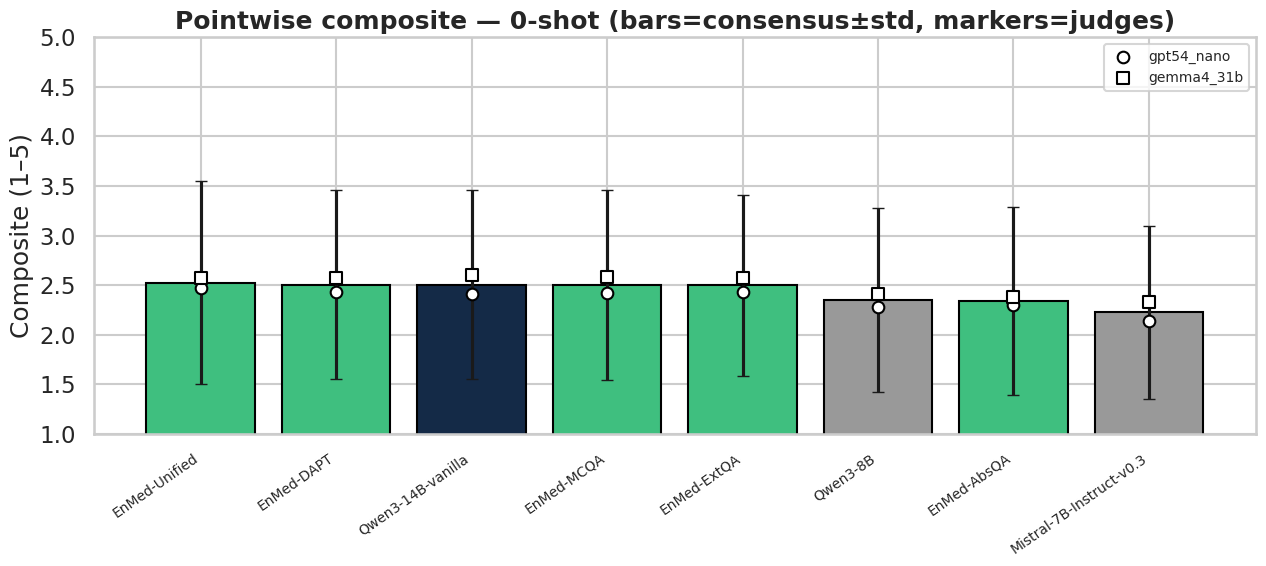

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_multijudge/fig_pointwise_composite_shot0.png


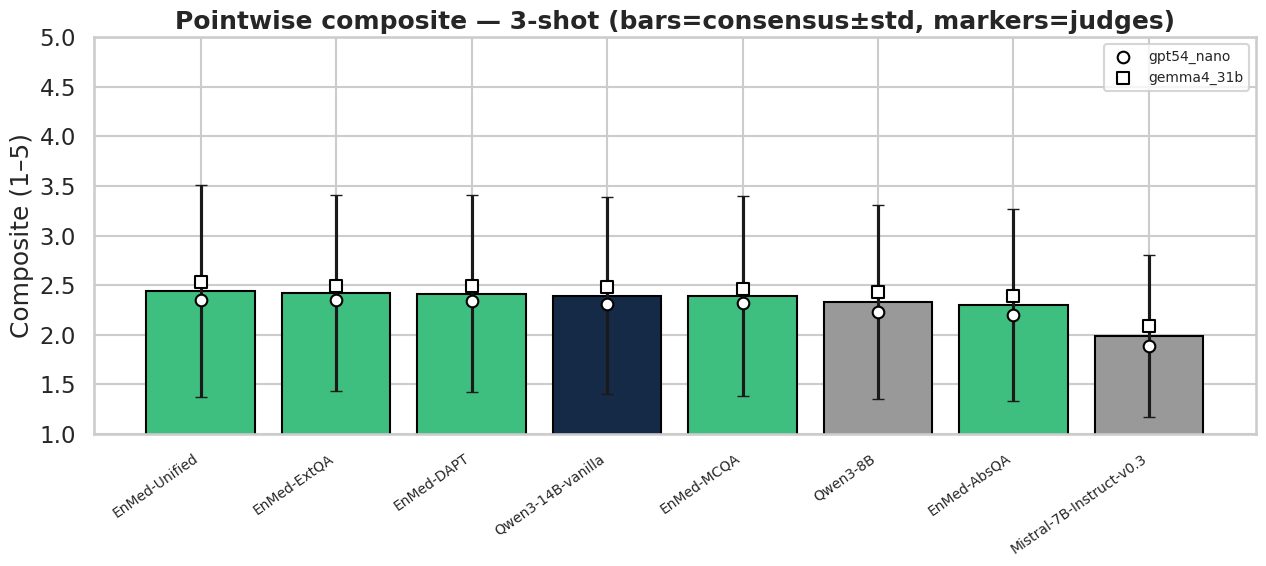

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_multijudge/fig_pointwise_composite_shot3.png


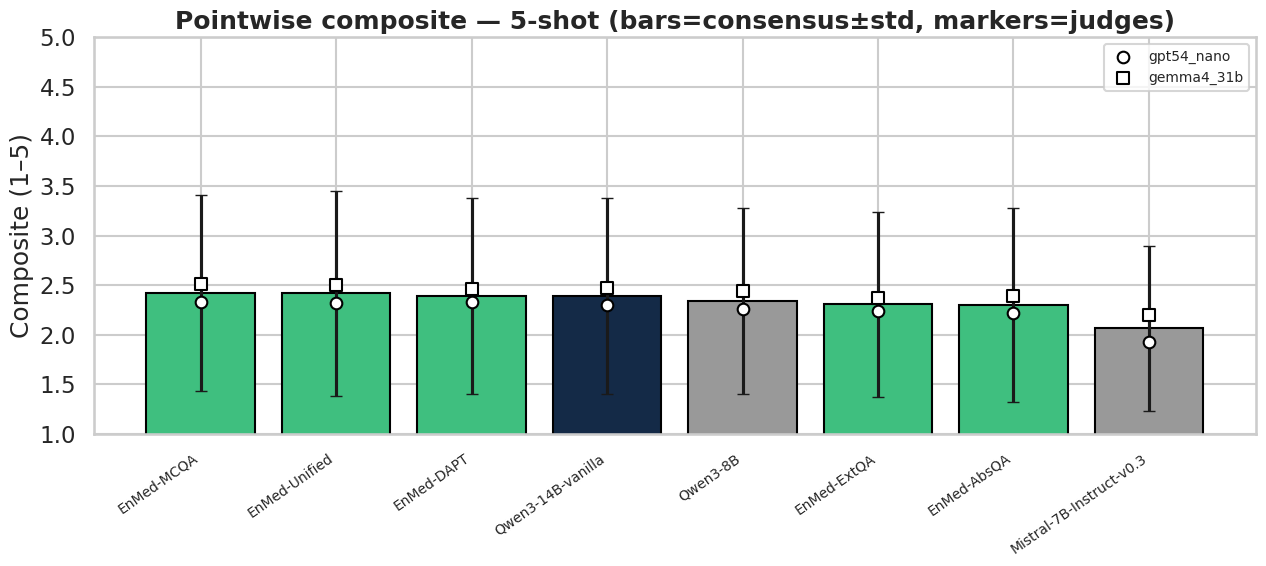

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_multijudge/fig_pointwise_composite_shot5.png


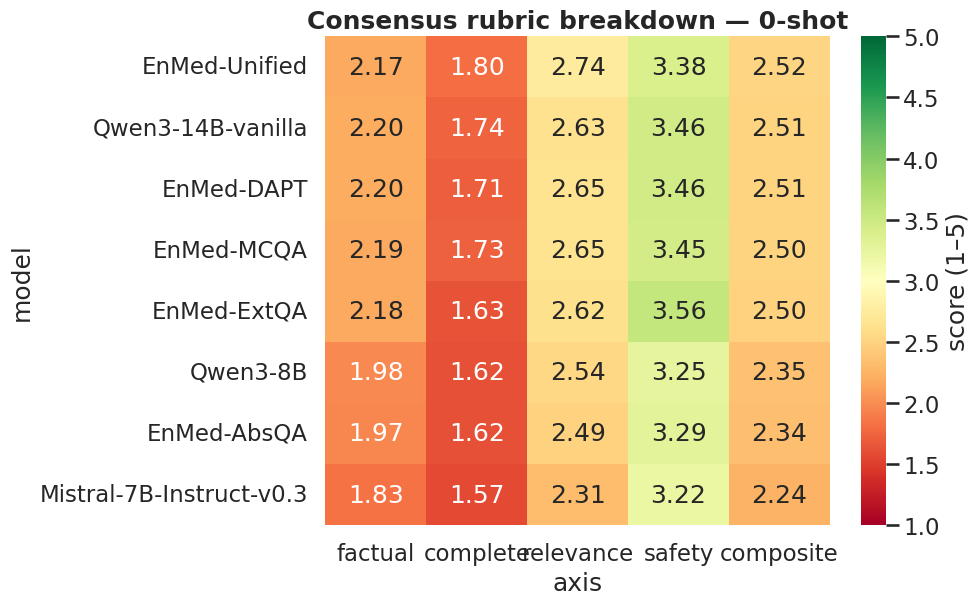

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_multijudge/fig_rubric_heatmap_shot0.png


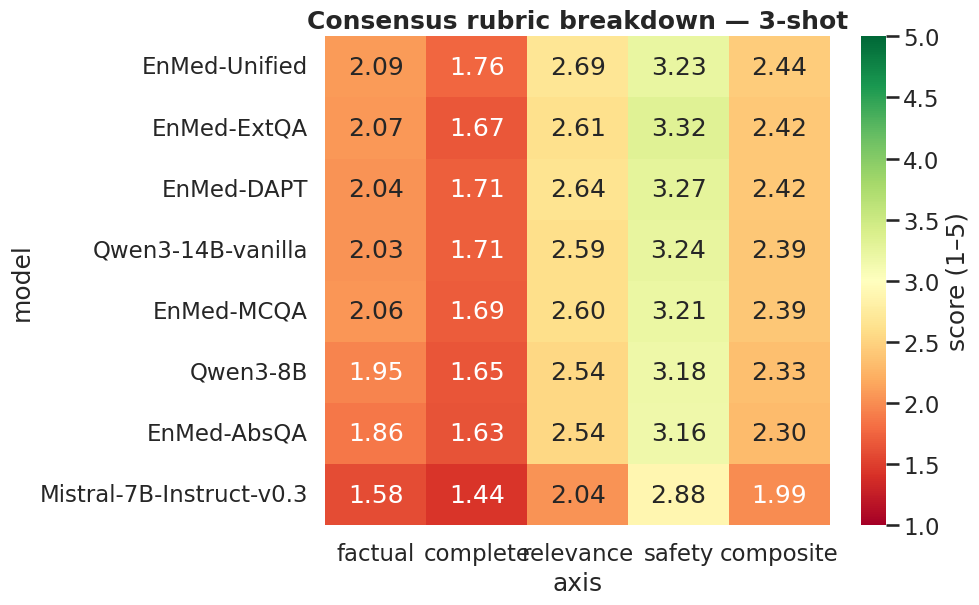

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_multijudge/fig_rubric_heatmap_shot3.png


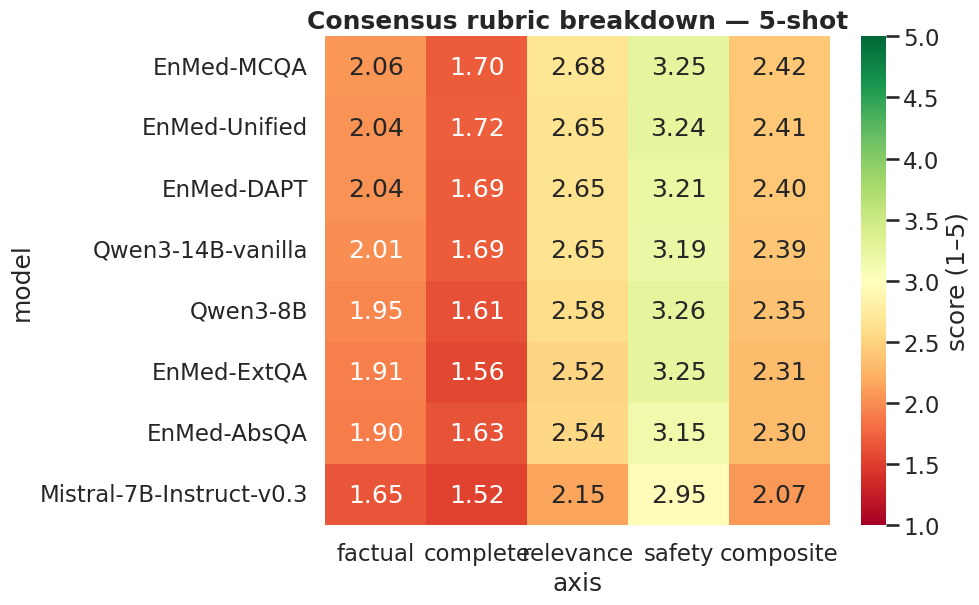

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_multijudge/fig_rubric_heatmap_shot5.png


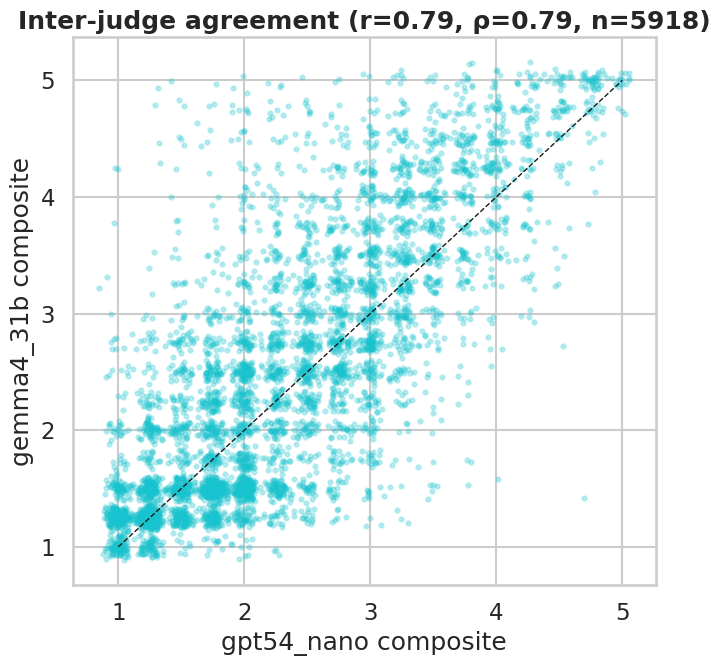

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_multijudge/fig_judge_agreement.png


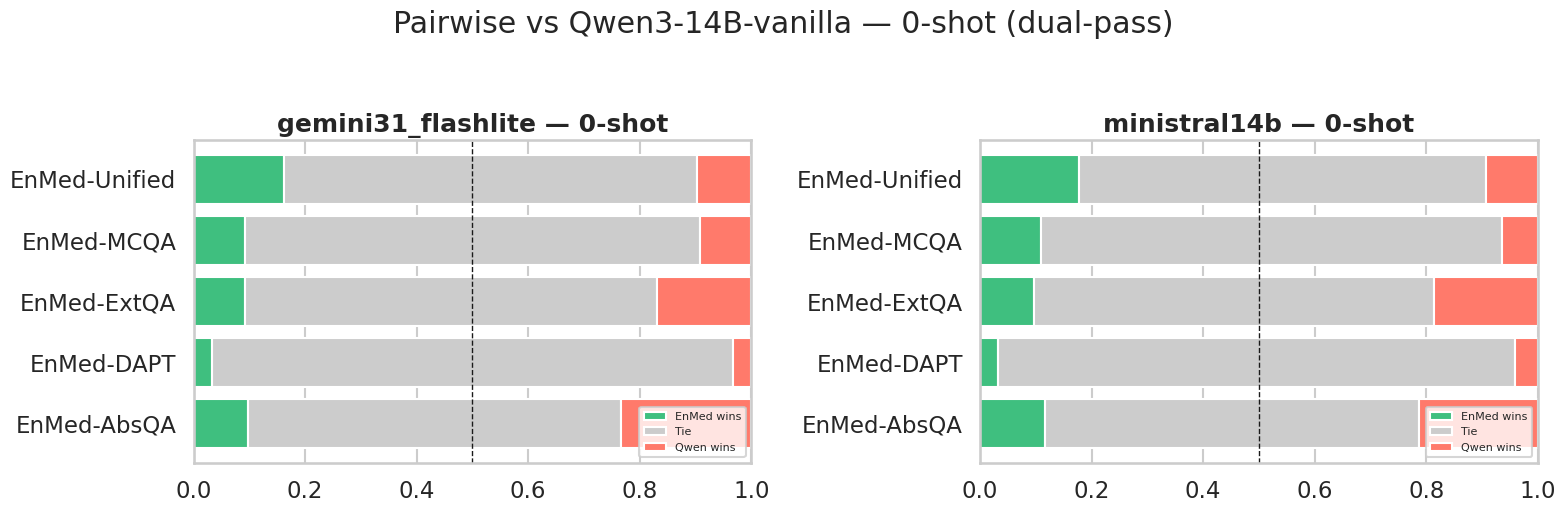

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_multijudge/fig_pairwise_wtl_shot0.png


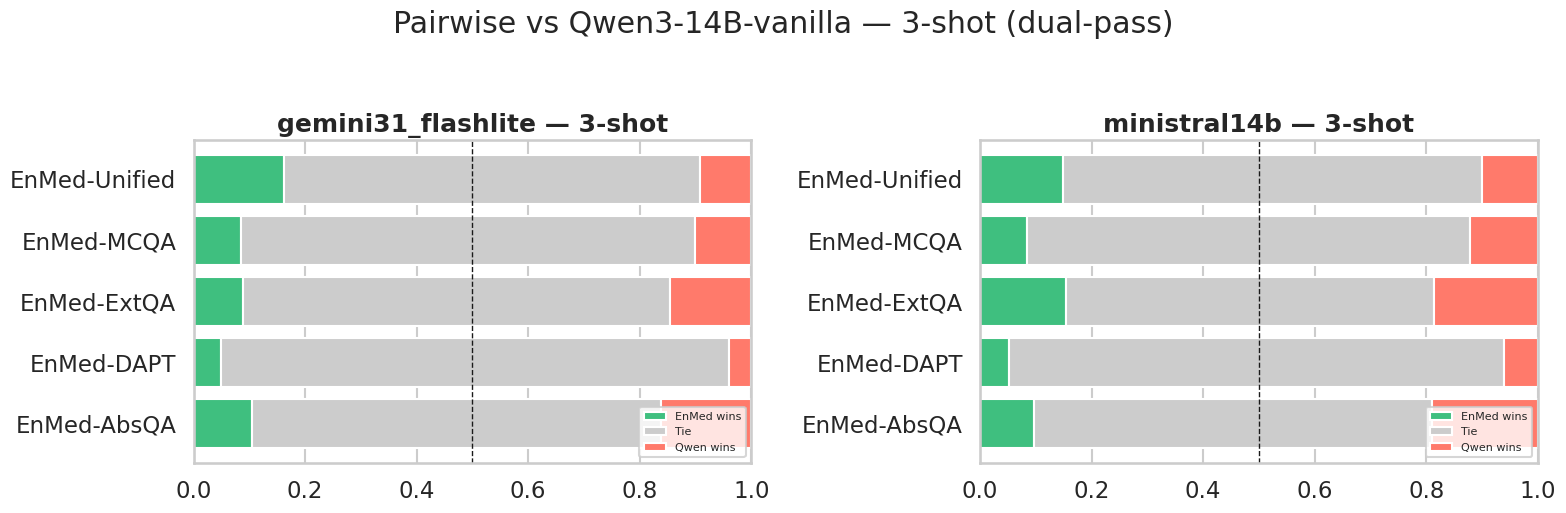

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_multijudge/fig_pairwise_wtl_shot3.png


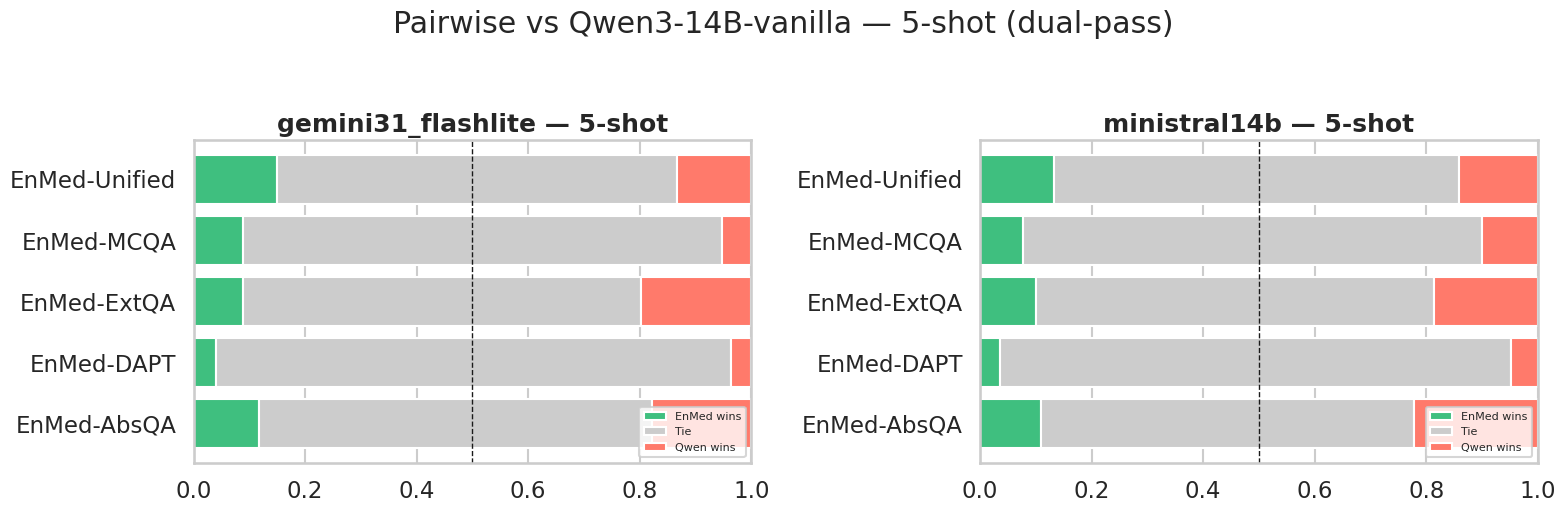

✓ /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_multijudge/fig_pairwise_wtl_shot5.png


In [9]:
# Stage 6 — Deep-analysis figures
# 1) Consensus composite bars, per-judge markers overlaid
for shot in SHOTS:
    sub = df_pointwise[df_pointwise["n_shot"] == shot].sort_values(
        "consensus_mean", ascending=False)
    if sub.empty: continue
    fig, ax = plt.subplots(figsize=(13, 6))
    x = np.arange(len(sub))
    ax.bar(x, sub["consensus_mean"], yerr=sub["consensus_std"], capsize=4,
           color=[GROUP_STYLE.get(model_group(m), {}).get("color", "white") for m in sub["model"]],
           edgecolor="black")
    for _bar, _m in zip(ax.patches, sub["model"]):
        _bar.set_hatch(GROUP_STYLE.get(model_group(_m), {}).get("hatch", ""))
    for j, mk in zip([j["name"] for j in ABS_JUDGES], ["o","s"]):
        col = f"{j}_mean"
        if col in sub.columns:
            ax.scatter(x, sub[col], marker=mk, color="white", edgecolor="black",
                       zorder=3, s=70, label=j)
    ax.set_xticks(x); ax.set_xticklabels(sub["model"], rotation=35, ha="right", fontsize=10)
    ax.set_ylabel("Composite (1–5)"); ax.set_ylim(1, 5)
    ax.set_title(f"Pointwise composite — {shot}-shot (bars=consensus±std, markers=judges)")
    ax.legend(fontsize=10)
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f"fig_pointwise_composite_shot{shot}.png")
    plt.savefig(out, bbox_inches="tight"); plt.show(); print(f"✓ {out}")

# 2) Per-axis consensus heatmap
cons_axis = (df_axis.groupby(["model","n_shot","axis"])["mean"]
             .mean().reset_index())          # mean across judges
for shot in SHOTS:
    sub = cons_axis[cons_axis["n_shot"] == shot]
    if sub.empty: continue
    piv = sub.pivot(index="model", columns="axis", values="mean") \
             .reindex(columns=["factual","complete","relevance","safety","composite"])
    piv = piv.sort_values("composite", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 0.55*len(piv) + 2))
    sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn", vmin=1, vmax=5,
                cbar_kws={"label": "score (1–5)"}, ax=ax)
    ax.set_title(f"Consensus rubric breakdown — {shot}-shot")
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f"fig_rubric_heatmap_shot{shot}.png")
    plt.savefig(out, bbox_inches="tight"); plt.show(); print(f"✓ {out}")

# 3) Inter-judge agreement scatter (per item, all models pooled)
j1, j2 = ABS_JUDGES[0]["name"], ABS_JUDGES[1]["name"]
xs, ys = [], []
for (m, s), _d in consensus_items.items():
    d1 = item_scores.get((j1, m, s), {}); d2 = item_scores.get((j2, m, s), {})
    for rid in set(d1) & set(d2):
        xs.append(d1[rid]); ys.append(d2[rid])
if len(xs) >= 3:
    xs, ys = np.array(xs), np.array(ys)
    pear = stats.pearsonr(xs, ys); spear = stats.spearmanr(xs, ys)
    rng = np.random.default_rng(42)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(xs + rng.normal(0, .05, len(xs)), ys + rng.normal(0, .05, len(ys)),
               s=10, alpha=0.25, color="#17C3CE")
    ax.plot([1, 5], [1, 5], "k--", lw=1)
    ax.set_xlabel(f"{j1} composite"); ax.set_ylabel(f"{j2} composite")
    ax.set_title(f"Inter-judge agreement (r={pear.statistic:.2f}, "
                 f"ρ={spear.statistic:.2f}, n={len(xs)})")
    plt.tight_layout()
    out = os.path.join(FIG_DIR, "fig_judge_agreement.png")
    plt.savefig(out, bbox_inches="tight"); plt.show(); print(f"✓ {out}")
    JUDGE_AGREEMENT = {"pearson_r": float(pear.statistic), "pearson_p": float(pear.pvalue),
                       "spearman_rho": float(spear.statistic), "n": int(len(xs)),
                       "mean_offset": float((xs - ys).mean())}
else:
    JUDGE_AGREEMENT = None

# 4) Pairwise stacked W/T/L per referee, one figure per (axis, shot)
if not df_pairwise.empty:
    judges = df_pairwise["judge"].unique().tolist()
    for axis_name in sorted(df_pairwise["axis"].unique()):
        for shot in SHOTS:
            subS = df_pairwise[(df_pairwise["axis"] == axis_name) & (df_pairwise["n_shot"] == shot)]
            if subS.empty: continue
            fig, axes2 = plt.subplots(1, len(judges), figsize=(8*len(judges), 5), squeeze=False)
            for ax, jname in zip(axes2[0], judges):
                sub = subS[subS["judge"] == jname]
                if sub.empty: ax.axis("off"); continue
                lbl = sub["challenger_model"] + "  vs  " + sub["opponent_model"]
                tot = (sub["wins"] + sub["losses"] + sub["ties"]).replace(0, 1)
                ax.barh(lbl, sub["wins"]/tot, color="black", label="challenger wins")
                ax.barh(lbl, sub["ties"]/tot, left=sub["wins"]/tot,
                        color="0.75", hatch="///", edgecolor="black", label="tie")
                ax.barh(lbl, sub["losses"]/tot, left=(sub["wins"]+sub["ties"])/tot,
                        color="white", hatch="xx", edgecolor="black", label="opponent wins")
                ax.axvline(0.5, color="k", ls="--", lw=1)
                ax.set_xlim(0, 1); ax.set_title(f"{jname} — {shot}-shot")
                ax.tick_params(axis="y", labelsize=8)
                ax.legend(fontsize=8, loc="lower right")
            plt.suptitle(f"{axis_name} — {shot}-shot (dual-pass A/B + B/A)", y=1.04)
            plt.tight_layout()
            out = os.path.join(FIG_DIR, f"fig_nb9_pairwise_wtl_{axis_name}_shot{shot}.png")
            plt.savefig(out, bbox_inches="tight"); plt.show(); print(f"✓ {out}")


## 📐 Stage 7 — Deep analysis: significance tests

Item-level paired tests on the consensus composite (each matchup × shot, challenger vs the
vanilla Qwen on the same items): paired t, Wilcoxon, Cohen's d — plus the
pooled pairwise sign tests. All p-values BH-FDR corrected within each family.

In [10]:
# Stage 7 — Paired significance on consensus items + FDR
# Runs on every matchup axis: PPL vs Vanilla, NoPPL vs Vanilla, PPL vs NoPPL.
sig_rows = []
for challenger, opponent, axis in MATCHUPS:
    for shot in SHOTS:
        d_c = consensus_items.get((challenger, shot), {})
        d_o = consensus_items.get((opponent, shot), {})
        common = sorted(set(d_c) & set(d_o))
        if len(common) < 5: continue
        a = np.array([d_c[r] for r in common])
        b = np.array([d_o[r] for r in common])
        diff = a - b
        t_stat, p_t = stats.ttest_rel(a, b)
        try:
            _, p_w = stats.wilcoxon(a, b) if not np.all(diff == 0) else (np.nan, 1.0)
        except ValueError:
            p_w = 1.0
        sig_rows.append({"challenger": challenger, "opponent": opponent, "axis": axis,
                         "n_shot": shot, "n": len(common),
                         "mean_challenger": a.mean(), "mean_opponent": b.mean(),
                         "delta": diff.mean(),
                         "cohens_d": diff.mean() / (diff.std(ddof=1) + 1e-12),
                         "p_ttest": p_t, "p_wilcoxon": p_w})
df_sig = pd.DataFrame(sig_rows)
if not df_sig.empty:
    df_sig["p_primary"] = df_sig["p_wilcoxon"].fillna(df_sig["p_ttest"]).fillna(1.0)
    rej, p_bh, _, _ = multipletests(df_sig["p_primary"], alpha=0.05, method="fdr_bh")
    df_sig["p_fdr_bh"], df_sig["sig_fdr"] = p_bh, rej
    df_sig.to_csv(os.path.join(OUT_DIR, "pointwise_paired_tests.csv"), index=False)
    print("── Item-level paired tests (consensus composite, per matchup axis) ──")
    print(df_sig.round(4).to_string(index=False))

# Pooled pairwise sign tests + FDR (across referees) — broken by axis
df_pool = pd.DataFrame()
if not df_pairwise.empty:
    group_keys = ["challenger_model", "n_shot"]
    if "axis" in df_pairwise.columns:
        group_keys = ["axis", "challenger_model", "n_shot"]
    df_pool = df_pairwise.groupby(group_keys).agg(
        wins=("wins","sum"), losses=("losses","sum"), ties=("ties","sum")).reset_index()
    df_pool["n_dec"]    = df_pool["wins"] + df_pool["losses"]
    df_pool["win_rate"] = df_pool["wins"] / df_pool["n_dec"].replace(0, np.nan)
    df_pool["net_preference"] = (df_pool["wins"] - df_pool["losses"]) / \
        (df_pool["wins"] + df_pool["losses"] + df_pool["ties"]).replace(0, np.nan)
    df_pool["p_sign"] = [binomtest(int(w), int(n), 0.5).pvalue if n else np.nan
                         for w, n in zip(df_pool["wins"], df_pool["n_dec"])]
    ok = df_pool["p_sign"].notna()
    if ok.any():
        rej, p_bh, _, _ = multipletests(df_pool.loc[ok, "p_sign"], alpha=0.05,
                                        method="fdr_bh")
        df_pool.loc[ok, "p_fdr_bh"], df_pool.loc[ok, "sig_fdr"] = p_bh, rej
    df_pool.to_csv(os.path.join(OUT_DIR, "pairwise_pooled_tests.csv"), index=False)
    print("\n── Pooled pairwise sign tests (per matchup axis) ──")
    print(df_pool.round(4).to_string(index=False))


── Item-level paired tests (consensus composite) ──
  enmed_model  n_shot   n  mean_enmed  mean_qwen   delta  cohens_d  p_ttest  p_wilcoxon  p_primary  p_fdr_bh  sig_fdr
  EnMed-AbsQA       0 248      2.3427     2.5035 -0.1608   -0.2436   0.0002      0.0004     0.0004    0.0062     True
  EnMed-AbsQA       3 248      2.3009     2.3936 -0.0927   -0.1460   0.0224      0.0090     0.0090    0.0675    False
  EnMed-AbsQA       5 248      2.3039     2.3891 -0.0852   -0.1260   0.0483      0.0252     0.0252    0.1259    False
   EnMed-DAPT       0 248      2.5071     2.5035  0.0035    0.0120   0.8497      0.9189     0.9189    0.9638    False
   EnMed-DAPT       3 248      2.4158     2.3936  0.0222    0.0539   0.3972      0.5530     0.5530    0.8343    False
   EnMed-DAPT       5 248      2.3952     2.3891  0.0060    0.0174   0.7844      0.6136     0.6136    0.8343    False
  EnMed-ExtQA       0 248      2.4980     2.5035 -0.0055   -0.0109   0.8634      0.9638     0.9638    0.9638    False
  En

## 📐 Stage 7b — Matchup-axis breakdown (PPL vs NoPPL added)

In [ ]:
# ─── Per-axis matchup summary (added: PPL vs NoPPL breakdown) ─────────────
if not df_sig.empty and "axis" in df_sig.columns:
    print("═" * 74)
    print("  MATCHUP-AXIS SUMMARY (pointwise consensus, item-level paired)")
    print("═" * 74)
    for axis_name, group in df_sig.groupby("axis"):
        n_sig_wins   = int(((group.get("sig_fdr", False)) & (group["delta"] > 0)).sum())
        n_sig_losses = int(((group.get("sig_fdr", False)) & (group["delta"] < 0)).sum())
        mean_delta   = group["delta"].mean()
        n_cells      = len(group)
        print(f"\n  {axis_name}  ({n_cells} cells)")
        print(f"    mean Δ (challenger − opponent) = {mean_delta:+.4f}")
        print(f"    significant wins   (FDR<.05) : {n_sig_wins}/{n_cells}")
        print(f"    significant losses (FDR<.05) : {n_sig_losses}/{n_cells}")

    # Save axis-broken CSV
    df_sig.to_csv(os.path.join(OUT_DIR, "matchup_axis_significance.csv"), index=False)
    print(f"\n  → matchup_axis_significance.csv written to {OUT_DIR}")

if "df_pool" in globals() and not df_pool.empty and "axis" in df_pairwise.columns:
    print("\n" + "═" * 74)
    print("  PAIRWISE REFEREE VERDICTS BY AXIS")
    print("═" * 74)
    for axis_name, group in df_pool.groupby("axis") if "axis" in df_pool.columns else []:
        wins   = int(group["wins"].sum())
        losses = int(group["losses"].sum())
        ties   = int(group["ties"].sum())
        total  = wins + losses + ties
        if total > 0:
            print(f"  {axis_name:22s}  wins={wins:4d}  losses={losses:4d}  ties={ties:4d}  "
                  f"win_rate={wins/(wins+losses+1e-9):.1%}")


## 🧠 Stage 8 — Deep analysis synthesis (auto-written report)

Reconciles both paradigms and all four judges into one conservative verdict per
(matchup axis × shot). Written to `RESULT/multijudge_deep_analysis/deep_analysis_report.md`.

In [11]:
# Stage 8 — Synthesis report (per-axis breakdown: PPL vs Vanilla / NoPPL vs Vanilla / PPL vs NoPPL)
L = ["# Multi-Judge Deep Analysis — Three-Group Comparison", f"_Generated {now_ts()}_", ""]
L.append("**Pointwise judges**: " + ", ".join(f"`{j['model']}`" for j in ABS_JUDGES))
L.append("**Pairwise referees**: " + ", ".join(f"`{j['model']}`" for j in PAIR_JUDGES)
         + " · dual-pass A/B+B/A")
L.append("")
L.append("**Matchup axes**:")
L.append("- **A_PPL_vs_Vanilla**  — does PPL adaptation beat the vanilla baseline?")
L.append("- **B_NoPPL_vs_Vanilla** — does NoPPL adaptation beat the vanilla baseline?")
L.append("- **C_PPL_vs_NoPPL**    — is perplexity filtering worth it?")
L.append("")

L.append("## 1. Pointwise landscape (all systems)")
L.append("```\n" + df_pointwise.round(3).to_string(index=False) + "\n```")
if JUDGE_AGREEMENT:
    r = JUDGE_AGREEMENT
    L.append(f"\nInter-judge agreement on {r['n']} shared items: Pearson r = "
             f"{r['pearson_r']:.3f}, Spearman ρ = {r['spearman_rho']:.3f}, "
             f"mean offset = {r['mean_offset']:+.3f}. "
             + ("The consensus composite is a stable primary metric."
                if r["pearson_r"] >= 0.6 else
                "Agreement is weak — per-judge scores should be reported "
                "separately and pairwise evidence weighted more heavily."))

L.append("\n## 2. Per-axis verdicts")
if not df_sig.empty and "axis" in df_sig.columns:
    for axis_name in sorted(df_sig["axis"].unique()):
        sub = df_sig[df_sig["axis"] == axis_name]
        n_cells = len(sub)
        sig_wins   = int(((sub.get("sig_fdr", False)) & (sub["delta"] > 0)).sum())
        sig_losses = int(((sub.get("sig_fdr", False)) & (sub["delta"] < 0)).sum())
        mean_d     = sub["delta"].mean()
        L.append(f"\n### {axis_name}")
        L.append(f"- cells tested: **{n_cells}**")
        L.append(f"- mean Δ (challenger − opponent): **{mean_d:+.4f}**")
        L.append(f"- significant wins (FDR<.05): **{sig_wins}/{n_cells}**")
        L.append(f"- significant losses (FDR<.05): **{sig_losses}/{n_cells}**")
        L.append("```\n" + sub[["challenger","opponent","n_shot","delta","cohens_d",
                                 "p_ttest","p_wilcoxon","p_fdr_bh","sig_fdr"]].round(4)
                            .to_string(index=False) + "\n```")

L.append("\n## 3. Pairwise landscape")
if not df_pairwise.empty:
    L.append("```\n" + df_pairwise.round(3).to_string(index=False) + "\n```")
    pc = df_pairwise["position_consistency"].dropna()
    if len(pc):
        L.append(f"\nMean position consistency: {pc.mean():.0%} — "
                 + ("verdicts are order-robust."
                    if pc.mean() >= 0.8 else
                    "notable order sensitivity; contradictory passes were "
                    "counted as ties (conservative)."))
else:
    L.append("_No pairwise data._")

report_path = os.path.join(OUT_DIR, "deep_analysis_report.md")
with open(report_path, "w", encoding="utf-8") as f: f.write("\n".join(L))
print(f"✓ Report written → {report_path}")


# Multi-Judge Deep Analysis — EnToFrMedicaLLM
_Generated 2026-07-22_10-10-49_

**Pointwise judges**: `openai/gpt-5.4-nano`, `google/gemma-4-31b-it`
**Pairwise referees**: `mistralai/ministral-14b-2512`, `google/gemini-3.1-flash-lite` · opponent `Qwen3-14B-vanilla` · dual-pass A/B+B/A

## 1. Pointwise landscape
```
                   model  n_shot   n  consensus_mean  consensus_std  gpt54_nano_mean  gpt54_nano_std  gemma4_31b_mean  gemma4_31b_std
             EnMed-AbsQA       0 248           2.343          0.951            2.304           0.923            2.381           1.117
             EnMed-AbsQA       3 248           2.301          0.970            2.202           0.927            2.395           1.111
             EnMed-AbsQA       5 248           2.304          0.978            2.217           0.939            2.391           1.130
              EnMed-DAPT       0 248           2.507          0.953            2.436           0.916            2.574           1.086
              

## 🏁 Stage 9 — Done

In [12]:
print("═" * 72)
print(f"  NB9 (MULTI-JUDGE EVAL + DEEP ANALYSIS) COMPLETE — {now_ts()}")
print("═" * 72)
print(f"  Judge scores  : {LLM_JUDGE_OUT}")
print(f"  Pairwise      : {PAIRWISE_OUT}")
print(f"  Tables (CSV)  : {OUT_DIR}")
print(f"  Figures       : {FIG_DIR}")
print(f"  Report        : {os.path.join(OUT_DIR, 'deep_analysis_report.md')}")

════════════════════════════════════════════════════════════════════════
  NB9 (MULTI-JUDGE EVAL + DEEP ANALYSIS) COMPLETE — 2026-07-22_10-10-49
════════════════════════════════════════════════════════════════════════
  Judge scores  : /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/EVALS/llm_judge_scores.json
  Pairwise      : /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/EVALS/pairwise_judge_results.json
  Tables (CSV)  : /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/multijudge_deep_analysis
  Figures       : /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/figures_multijudge
  Report        : /content/drive/MyDrive/00_PHD_THESIS/CODE/05-05-26/RESULT/multijudge_deep_analysis/deep_analysis_report.md
